# 05 — Lógica de Proyección Banco 1 → Bancos 2-4
**Objetivo:** Explorar métodos para proyectar la clasificación mineral/desmonte desde el banco con datos reales hacia los bancos inferiores.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

BH_PATH = Path('../Documentacion/Referencias/Datos Demo/Data_BH')

collar = pd.read_csv(BH_PATH / 'collar.csv')
assay  = pd.read_csv(BH_PATH / 'assay.csv')
litho  = pd.read_csv(BH_PATH / 'litho.csv')

df = collar.merge(assay[['HOLEID','CU','MO']], on='HOLEID', how='left')\
           .merge(litho[['HOLEID','MINZONE','LITH1']], on='HOLEID', how='left')

print(f'Dataset: {df.shape}')
print(f'Bancos: {sorted(df["BANCO"].dropna().unique())}')

Dataset: (18604, 21)
Bancos: [np.int64(4450), np.int64(4465), np.int64(4480), np.int64(4495)]


## 1. Identificar bancos con y sin datos reales
El concepto del Ore Projector: banco con datos reales = banco fuente; bancos sin datos = se proyectan.

In [2]:
cobertura = df.groupby('BANCO').agg(
    n_pozos=('HOLEID', 'count'),
    n_con_cu=('CU', 'count'),
    cu_mean=('CU', 'mean'),
).round(3)
cobertura['pct_cu'] = (cobertura['n_con_cu'] / cobertura['n_pozos'] * 100).round(1)
cobertura['tiene_datos'] = cobertura['pct_cu'] > 50
print(cobertura.sort_index())

# Banco fuente = el que tiene mayor cobertura de CU
banco_fuente = cobertura['pct_cu'].idxmax()
print(f'\n→ Banco fuente identificado: {banco_fuente}')

       n_pozos  n_con_cu  cu_mean  pct_cu  tiene_datos
BANCO                                                 
4450       701       625    1.440    89.2         True
4465      7221      6820    0.773    94.4         True
4480     10674      9727    0.686    91.1         True
4495         8         6    1.900    75.0         True

→ Banco fuente identificado: 4465


## 2. Enfoque 1 — Vecino más cercano (NN) entre bancos

In [3]:
from scipy.spatial import cKDTree

# Banco fuente
src = df[(df['BANCO'] == banco_fuente) & df['CU'].notna()][['EAST', 'NORTH', 'CU', 'MINZONE']].copy()
tree = cKDTree(src[['EAST', 'NORTH']].values)

# Proyectar a un banco objetivo
bancos_objetivo = [b for b in sorted(df['BANCO'].dropna().unique()) if b != banco_fuente]

resultados = []
for banco in bancos_objetivo[:3]:  # primeros 3 bancos objetivo
    tgt = df[df['BANCO'] == banco][['HOLEID', 'EAST', 'NORTH']].copy()
    if len(tgt) == 0:
        continue
    dist, idx = tree.query(tgt[['EAST', 'NORTH']].values, k=1)
    tgt['CU_proyectado'] = src.iloc[idx]['CU'].values
    tgt['MINZONE_proyectado'] = src.iloc[idx]['MINZONE'].values
    tgt['dist_vecino'] = dist
    tgt['BANCO'] = banco
    resultados.append(tgt)

if resultados:
    df_proj = pd.concat(resultados, ignore_index=True)
    print(df_proj.groupby('BANCO')[['CU_proyectado', 'dist_vecino']].describe().round(3))

      CU_proyectado                                                    \
              count   mean    std    min    25%    50%    75%     max   
BANCO                                                                   
4450          701.0  1.668  1.690  0.062  0.511  1.130  2.282  10.630   
4480        10674.0  0.685  1.083  0.001  0.100  0.273  0.790  18.710   
4495            8.0  1.497  1.695  0.532  0.590  0.950  1.331   5.604   

      dist_vecino                                                       
            count   mean     std    min    25%    50%     75%      max  
BANCO                                                                   
4450        701.0  2.175   0.916  0.000  1.664  2.322   2.675    7.280  
4480      10674.0  9.379  12.918  0.000  2.079  3.479  12.564  102.096  
4495          8.0  1.851   0.443  1.496  1.530  1.599   2.168    2.638  


## 3. Visualización — Banco fuente vs proyectado

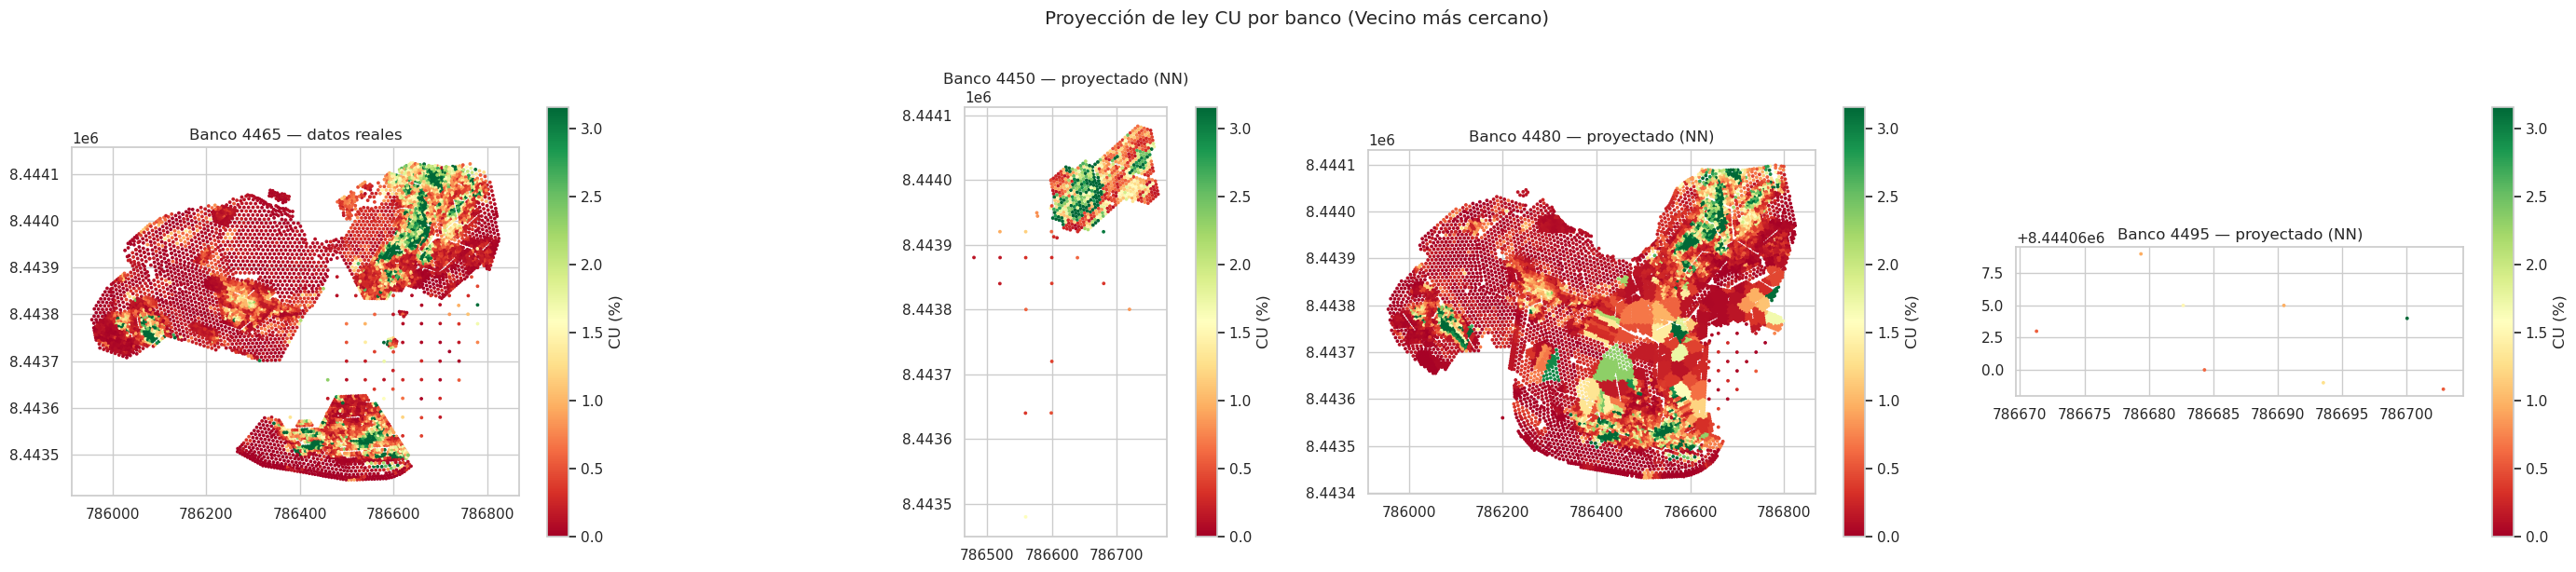

In [4]:
if resultados:
    n_plots = 1 + len(resultados)
    fig, axes = plt.subplots(1, n_plots, figsize=(n_plots * 7, 6))

    vmax = src['CU'].quantile(0.95)

    # Banco fuente
    sc = axes[0].scatter(src['EAST'], src['NORTH'], c=src['CU'],
                          cmap='RdYlGn', s=3, vmin=0, vmax=vmax)
    plt.colorbar(sc, ax=axes[0], label='CU (%)')
    axes[0].set_title(f'Banco {int(banco_fuente)} — datos reales')
    axes[0].set_aspect('equal')

    # Bancos proyectados
    for i, tgt in enumerate(resultados):
        banco = tgt['BANCO'].iloc[0]
        sc = axes[i+1].scatter(tgt['EAST'], tgt['NORTH'], c=tgt['CU_proyectado'],
                                cmap='RdYlGn', s=3, vmin=0, vmax=vmax)
        plt.colorbar(sc, ax=axes[i+1], label='CU (%)')
        axes[i+1].set_title(f'Banco {int(banco)} — proyectado (NN)')
        axes[i+1].set_aspect('equal')

    plt.suptitle('Proyección de ley CU por banco (Vecino más cercano)', y=1.02)
    plt.tight_layout()
    plt.show()

## 4. Umbral de corte — clasificación mineral/desmonte
Con un cutoff de CU definido, se puede clasificar cada bloque proyectado.

In [5]:
CU_CUTOFF = 0.20  # % — ajustar según criterio Las Bambas

if resultados:
    df_proj['clasificacion'] = np.where(
        df_proj['CU_proyectado'] >= CU_CUTOFF, 'mineral', 'desmonte'
    )

    resumen = df_proj.groupby(['BANCO', 'clasificacion']).size().unstack(fill_value=0)
    resumen['pct_mineral'] = (resumen.get('mineral', 0) /
                               resumen.sum(axis=1) * 100).round(1)
    print(f'Cutoff CU = {CU_CUTOFF}%')
    print(resumen)

Cutoff CU = 0.2%
clasificacion  desmonte  mineral  pct_mineral
BANCO                                        
4450                 29      672         95.9
4480               4566     6108         57.2
4495                  0        8        100.0
